In [3]:
# Load packages
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statistics as st
import math as mt
import seaborn as sns
from arch.unitroot import ADF, KPSS
#!pip install arch has previously been run
from arch.unitroot.cointegration import phillips_ouliaris
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.ardl import UECM
from statsmodels.tsa.api import VAR
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from statsmodels.regression.linear_model import OLS

In [53]:
csvdashboard = pd.read_csv("C://dev/LehmannRiskDept/round 2/data/realDashboardData.csv")

df = pd.DataFrame(csvdashboard)
df_jams = df[df["product"] == "JAMS"]
df_djembes = df_jam = df[df["product"] == "DJEMBES"]

In [33]:
df.head(20)

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,1,0,SQUID_INK,1835,1,1834.0,22.0,NaN,NaN,1837,1,1838.0,21.0,NaN,NaN,1836.0,0.0
1,1,0,PICNIC_BASKET1,58706,1,58705.0,10.0,58704.0,27.0,58715,1,58716.0,10.0,58717.0,27.0,58710.5,0.0
2,1,0,PICNIC_BASKET2,30252,11,30251.0,27.0,NaN,NaN,30257,1,30258.0,37.0,NaN,NaN,30254.5,0.0
3,1,0,RAINFOREST_RESIN,9998,3,9996.0,1.0,9995.0,21.0,10004,1,10005.0,21.0,NaN,NaN,10001.0,0.0
4,1,0,KELP,2032,23,NaN,NaN,NaN,NaN,2035,22,NaN,NaN,NaN,NaN,2033.5,0.0
5,1,0,CROISSANTS,4274,123,NaN,NaN,NaN,NaN,4276,123,NaN,NaN,NaN,NaN,4275.0,0.0
6,1,0,JAMS,6541,255,NaN,NaN,NaN,NaN,6543,255,NaN,NaN,NaN,NaN,6542.0,0.0
7,1,0,DJEMBES,13409,62,NaN,NaN,NaN,NaN,13410,27,13411.0,35.0,NaN,NaN,13409.5,0.0
8,1,100,KELP,2032,26,NaN,NaN,NaN,NaN,2034,5,2035.0,26.0,NaN,NaN,2033.0,0.0
9,1,100,CROISSANTS,4275,48,4274.0,54.0,NaN,NaN,4276,102,NaN,NaN,NaN,NaN,4275.5,0.0


In [35]:
# Define the required columns and products
columns_to_keep = [
    'timestamp', 'product', 
    'bid_price_1', 'bid_volume_1', 
    'ask_price_1', 'ask_volume_1', 
    'mid_price'
]

products_to_keep = [
    'PICNIC_BASKET1', 'PICNIC_BASKET2', 
    'CROISSANTS', 'JAMS', 'DJEMBES'
]

# Filter the DataFrame
filtered_df = df[df['product'].isin(products_to_keep)][columns_to_keep]


In [37]:
filtered_df.head()

,timestamp,product,bid_price_1,bid_volume_1,ask_price_1,ask_volume_1,mid_price
1,0,PICNIC_BASKET1,58706,1,58715,1,58710.5
2,0,PICNIC_BASKET2,30252,11,30257,1,30254.5
5,0,CROISSANTS,4274,123,4276,123,4275.0
6,0,JAMS,6541,255,6543,255,6542.0
7,0,DJEMBES,13409,62,13410,27,13409.5


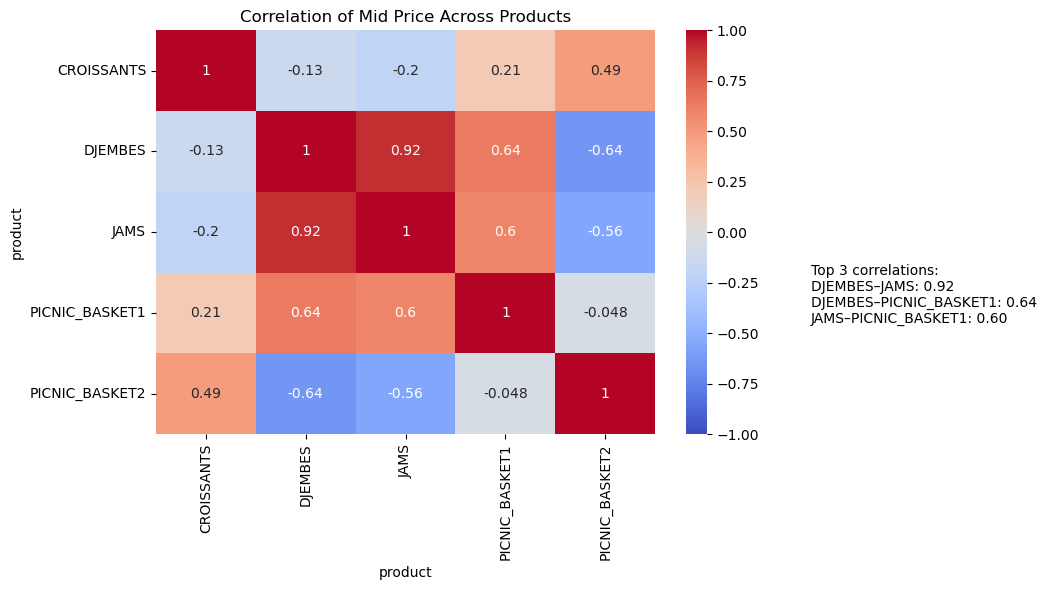

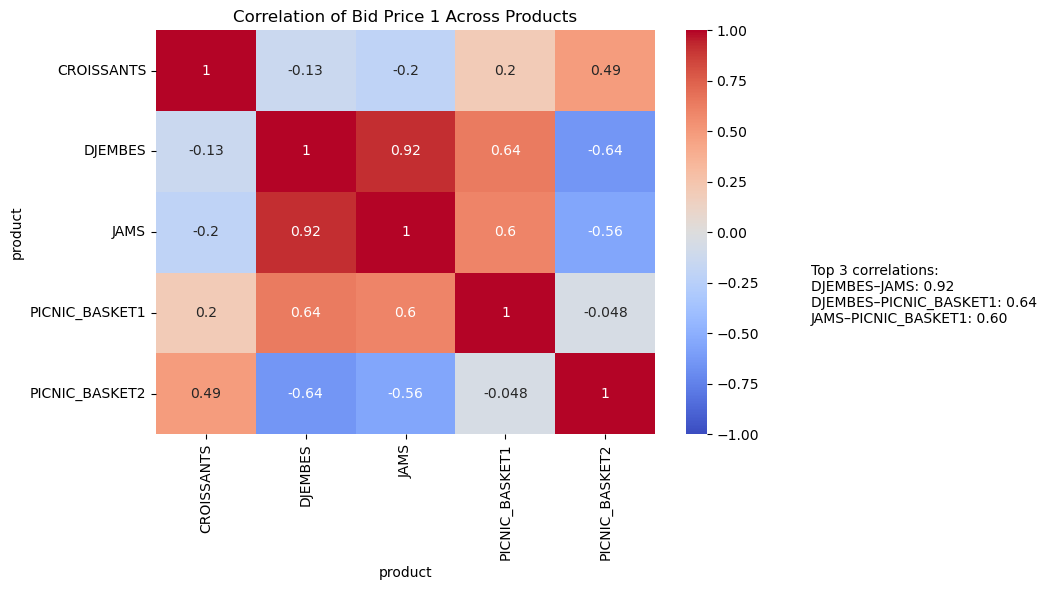

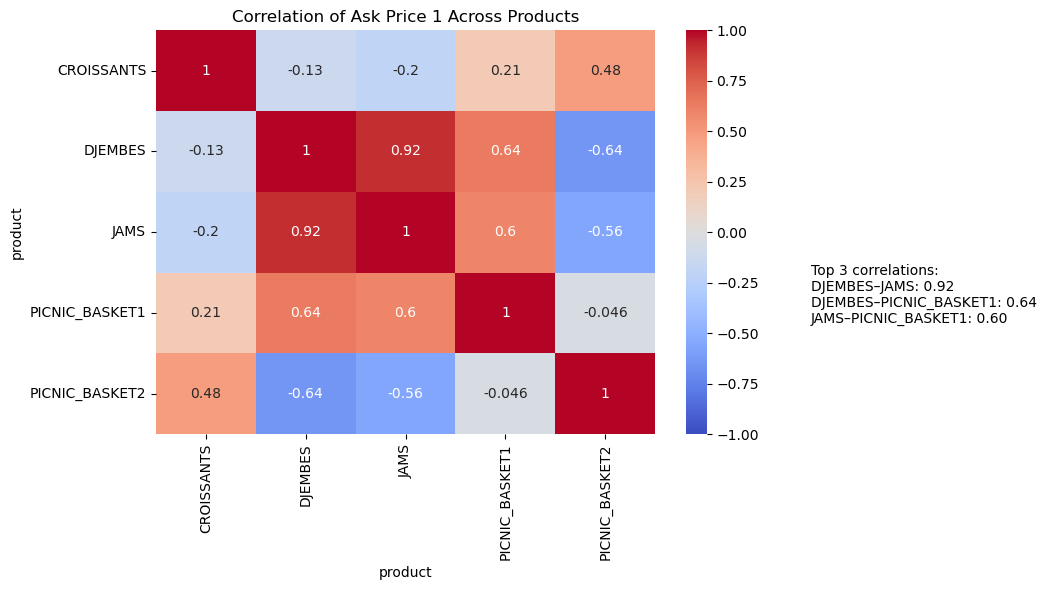

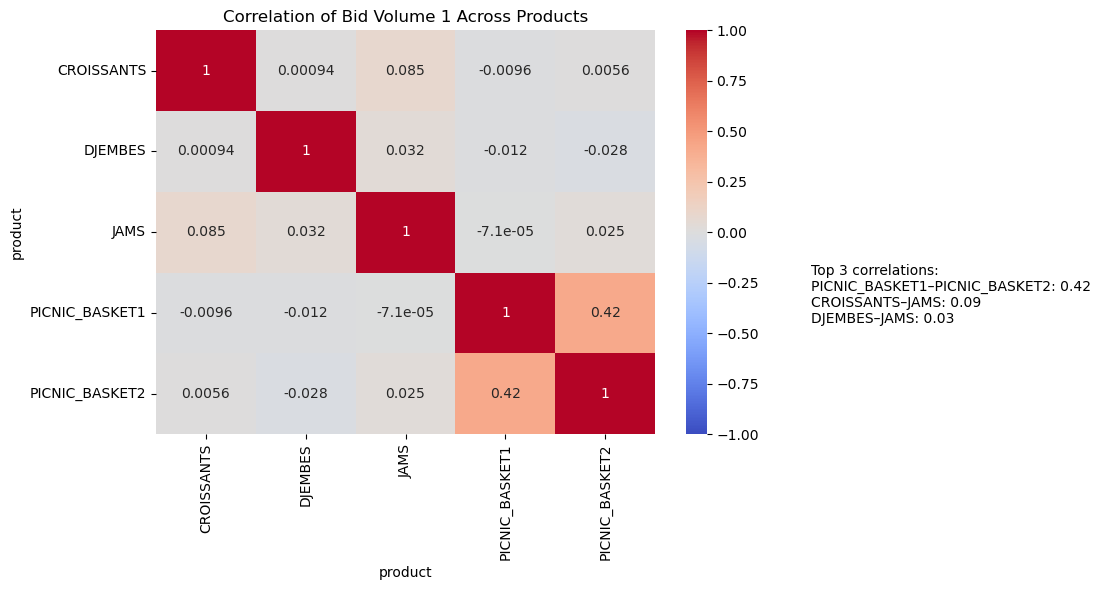

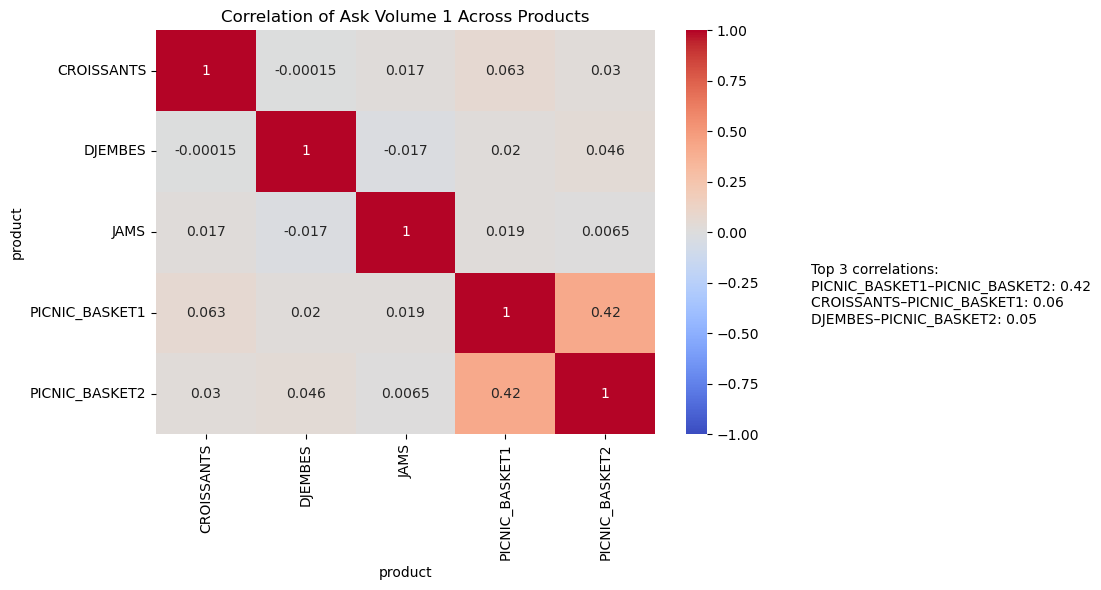

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define features of interest
features = ['mid_price', 'bid_price_1', 'ask_price_1', 'bid_volume_1', 'ask_volume_1']

# Create a dictionary to hold pivoted DataFrames and correlation matrices
pivoted_data = {}
correlations = {}

# Iterate over each feature to pivot and calculate correlation
for feature in features:
    pivot = filtered_df.pivot(index='timestamp', columns='product', values=feature)
    pivoted_data[feature] = pivot
    corr_matrix = pivot.corr()
    correlations[feature] = corr_matrix

    # Extract upper triangle of correlation matrix without diagonal
    mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    upper_triangle = corr_matrix.where(mask)
    
    # Flatten and sort
    corr_pairs = (
        upper_triangle.stack()
        .sort_values(ascending=False)
    )
    
    top3 = corr_pairs.head(3)

    # Prepare text for legend
    legend_text = '\n'.join(
        [f'{i[0]}–{i[1]}: {v:.2f}' for i, v in top3.items()]
    )

    # Plot heatmap
    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f'Correlation of {feature.replace("_", " ").title()} Across Products')

    # Add legend box
    plt.gcf().text(1.02, 0.5, f'Top 3 correlations:\n{legend_text}', fontsize=10, va='center')
    plt.tight_layout()
    plt.show()


In [57]:
df_djembes.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
7,1,0,DJEMBES,13409,62,NaN,NaN,NaN,NaN,13410,27,13411.0,35.0,NaN,NaN,13409.5,0.0
15,1,100,DJEMBES,13408,67,NaN,NaN,NaN,NaN,13410,67,NaN,NaN,NaN,NaN,13409.0,0.0
17,1,200,DJEMBES,13409,65,NaN,NaN,NaN,NaN,13410,65,NaN,NaN,NaN,NaN,13409.5,0.0
24,1,300,DJEMBES,13408,62,NaN,NaN,NaN,NaN,13410,62,NaN,NaN,NaN,NaN,13409.0,0.0
36,1,400,DJEMBES,13410,30,13409.0,38.0,NaN,NaN,13411,68,NaN,NaN,NaN,NaN,13410.5,0.0


In [81]:
# Rename 'mid_price' columns in both dataframes
df_jams_renamed = df_jams.rename(columns={'mid_price': 'mid_price_jams'})
df_djembes_renamed = df_djembes.rename(columns={'mid_price': 'mid_price_djembes'})

# Merge the dataframes on 'timestamp' and add suffixes to differentiate overlapping columns
merged_df = df_jams_renamed[['timestamp', 'mid_price_jams']].join(
    df_djembes_renamed[['timestamp', 'mid_price_djembes']], 
    on='timestamp', how='inner', 
    lsuffix='_jams', rsuffix='_djembes'
)

# Ensure the final dataframe has the desired columns
merged_df = merged_df[['timestamp', 'mid_price_jams', 'mid_price_djembes']]

# Check the result
print(merged_df)
# Rename 'mid_price' columns in both dataframes
df_jams_renamed = df_jams.rename(columns={'mid_price': 'mid_price_jams'})
df_djembes_renamed = df_djembes.rename(columns={'mid_price': 'mid_price_djembes'})

# Merge the dataframes on 'timestamp' and add suffixes to differentiate overlapping columns
merged_df = df_jams_renamed[['timestamp', 'mid_price_jams']].join(
    df_djembes_renamed[['timestamp', 'mid_price_djembes']], 
    on='timestamp', how='inner', 
    lsuffix='_jams', rsuffix='_djembes'
)

# Ensure the final dataframe has the desired columns
merged_df = merged_df[['timestamp', 'mid_price_jams', 'mid_price_djembes']]

# Check the result
print(merged_df)


     timestamp  mid_price_jams  mid_price_djembes
10         100          6542.0            13412.5
39         400          6541.0            13415.5
115       1400          6542.5            13414.5
157       1900          6542.0            13414.0
211       2600          6543.0            13413.5
217       2700          6543.0            13412.0
243       3000          6544.0            13399.5
301       3700          6544.0            13383.5
321       4000          6543.0            13386.5
407       5000          6543.0            13391.5
485       6000          6541.0            13378.5
507       6300          6541.0            13375.5
601       7500          6540.5            13372.5
612       7600          6540.0            13358.5
     timestamp  mid_price_jams  mid_price_djembes
10         100          6542.0            13412.5
39         400          6541.0            13415.5
115       1400          6542.5            13414.5
157       1900          6542.0            13414.0


In [83]:
merged_df.head()

,timestamp,mid_price_jams,mid_price_djembes
10,100,6542.0,13412.5
39,400,6541.0,13415.5
115,1400,6542.5,13414.5
157,1900,6542.0,13414.0
211,2600,6543.0,13413.5


In [85]:
# y= JAMS, X= djembes
constant = True
start = merged_df.index[0]         # First date in the index
end = merged_df.index[-1]          # Last date in the index
y_t = merged_df["mid_price_jams"].loc[start:end].dropna() # 
x_t = merged_df["mid_price_djembes"].loc[start:end].dropna()
x_t = x_t.reindex(y_t.index)
if constant == True:
    x_t = add_constant(x_t) # add intercept = columns of 1s to x_t
# OLS regression: Static Equilibrium Model
ols = OLS(y_t, x_t).fit()  # validate result with statsmodels
res = ols.resid

In [93]:
print(res.mean())

2.2997223173401186e-10
